In [1]:
import netCDF4 as net
from services.fvc_service               import FvcService
import warnings
import os
import glob
from services.read_ndvi_service         import ReadNdviService
from utilities.utilities_extraction_data import UtilitiesExtractionData
import numpy as np
import pandas as pd
import xarray as xr

In [2]:
warnings.filterwarnings("ignore")
os.environ['HDF5_DISABLE_VERSION_CHECK'] = '2'

In [3]:
month = '01'

In [4]:
files_myd_ = sorted(glob.glob('/home/sagonda/Documentos/git/projects/Prototype/myd21/2016/'+month+'/*.hdf'))
print(files_myd_)

['/home/sagonda/Documentos/git/projects/Prototype/myd21/2016/01/MYD21.A2016015.0025.061.2021341222436.hdf', '/home/sagonda/Documentos/git/projects/Prototype/myd21/2016/01/MYD21.A2016015.0030.061.2021341222410.hdf', '/home/sagonda/Documentos/git/projects/Prototype/myd21/2016/01/MYD21.A2016015.0035.061.2021341222351.hdf', '/home/sagonda/Documentos/git/projects/Prototype/myd21/2016/01/MYD21.A2016015.0040.061.2021341222430.hdf', '/home/sagonda/Documentos/git/projects/Prototype/myd21/2016/01/MYD21.A2016015.0045.061.2021341222513.hdf', '/home/sagonda/Documentos/git/projects/Prototype/myd21/2016/01/MYD21.A2016015.0050.061.2021341222334.hdf', '/home/sagonda/Documentos/git/projects/Prototype/myd21/2016/01/MYD21.A2016015.0055.061.2021341222328.hdf', '/home/sagonda/Documentos/git/projects/Prototype/myd21/2016/01/MYD21.A2016015.0100.061.2021341222330.hdf', '/home/sagonda/Documentos/git/projects/Prototype/myd21/2016/01/MYD21.A2016015.0105.061.2021341222334.hdf', '/home/sagonda/Documentos/git/projec

In [5]:
files_ = sorted(glob.glob('/media/sagonda/Elements1/2016/'+month+'/15/*Night.nc')) + sorted(glob.glob('/media/sagonda/Elements1/2016/'+month+'/15/*Both.nc'))
print(files_)

['/media/sagonda/Elements1/2016/01/15/TES_20160115_0040_Night.nc', '/media/sagonda/Elements1/2016/01/15/TES_20160115_0045_Night.nc', '/media/sagonda/Elements1/2016/01/15/TES_20160115_0050_Night.nc', '/media/sagonda/Elements1/2016/01/15/TES_20160115_0055_Night.nc', '/media/sagonda/Elements1/2016/01/15/TES_20160115_0100_Night.nc', '/media/sagonda/Elements1/2016/01/15/TES_20160115_0105_Night.nc', '/media/sagonda/Elements1/2016/01/15/TES_20160115_0110_Night.nc', '/media/sagonda/Elements1/2016/01/15/TES_20160115_0120_Night.nc', '/media/sagonda/Elements1/2016/01/15/TES_20160115_0220_Night.nc', '/media/sagonda/Elements1/2016/01/15/TES_20160115_0225_Night.nc', '/media/sagonda/Elements1/2016/01/15/TES_20160115_0230_Night.nc', '/media/sagonda/Elements1/2016/01/15/TES_20160115_0235_Night.nc', '/media/sagonda/Elements1/2016/01/15/TES_20160115_0240_Night.nc', '/media/sagonda/Elements1/2016/01/15/TES_20160115_0245_Night.nc', '/media/sagonda/Elements1/2016/01/15/TES_20160115_0250_Night.nc', '/media/s

In [6]:
def match_files(nc_files, hdf_files):
    test_list = []
    myd21_list = []

    for i in range(len(nc_files)):
        for j in range(len(hdf_files)):
            if nc_files[i].split('_')[-2] == hdf_files[j].split('.')[-4]:
                test_list.append(nc_files[i])
                myd21_list.append(hdf_files[j])
    print(len(test_list))
    print(len(myd21_list))
    return test_list, myd21_list

In [7]:
files, files_myd = match_files(files_, files_myd_)
del files_, files_myd_

117
117


In [8]:
data = [net.Dataset(file) for file in files]
data_myd = [net.Dataset(file) for file in files_myd]
# del files, files_myd

In [9]:
e32_original_list = [data[variable].variables['UVEG_e32'][:,:] for variable in range(len(data))]
e32_myd_list = [data_myd[variable].variables['Emis_32'][:,:] for variable in range(len(data_myd))]
del data_myd


In [10]:
e32_original_float = [(e32_original_list[var] * 0.002) + 0.49  for var in range(len(e32_original_list))]
e32_myd_float = [(e32_myd_list[var] * 0.002) + 0.49  for var in range(len(e32_myd_list))]
del e32_original_list, e32_myd_list


In [11]:
e32_original_float_mask = [ np.where(e32_original_float[i] > 0.49) for i in range(len(e32_original_float)) ]

In [12]:
e32_original_float_ = [ e32_original_float[i][e32_original_float_mask[i]] for i in range(len(e32_original_float)) ]
e32_myd_float_ = [ e32_myd_float[i][e32_original_float_mask[i]] for i in range(len(e32_myd_float)) ]

del e32_original_float, e32_myd_float

In [13]:
latitud = [data[var].variables['lat'][:,:][e32_original_float_mask[var]]/10000 for var in range(len(data))]
longitud = [data[var].variables['lon'][:,:][e32_original_float_mask[var]]/10000 for var in range(len(data))]
del data

In [14]:
latitud_ = np.array([latitud])
longitud_ = np.array([longitud])
latitud_con = np.concatenate((latitud_), axis=0)
longitud_con = np.concatenate((longitud_), axis=0)
del latitud, longitud, latitud_, longitud_

In [15]:
ndvi_lat, ndvi_lon, ndvi = ReadNdviService.read_ndvi_file('/media/sagonda/6D53615C4A88515D/data/ndvi/2016/', '2016', month)

####################
Read files NDVI.................
NDVI files upload!!
####################


In [16]:
ndvi_d = []
indices = []
for i in range(len(latitud_con)):
    try:
        print('Imagen:',i,'de:',len(latitud_con) )
        ndvi_ = UtilitiesExtractionData.extract_ndvi(latitud_con[i], longitud_con[i], ndvi_lat, ndvi_lon, ndvi)
        if ndvi_.size > 0:
            ndvi_d.append(ndvi_)
    except:
        print('Error imagen:',i,'de:',len(latitud_con) )
        indices.append(i)
        continue

Imagen: 0 de: 117
Imagen: 1 de: 117
Imagen: 2 de: 117
Imagen: 3 de: 117
Imagen: 4 de: 117
Imagen: 5 de: 117
Imagen: 6 de: 117
Imagen: 7 de: 117
Imagen: 8 de: 117
Imagen: 9 de: 117
Imagen: 10 de: 117
Imagen: 11 de: 117
Imagen: 12 de: 117
Imagen: 13 de: 117
Imagen: 14 de: 117
Imagen: 15 de: 117
Imagen: 16 de: 117
Imagen: 17 de: 117
Imagen: 18 de: 117
Imagen: 19 de: 117
Imagen: 20 de: 117
Imagen: 21 de: 117
Imagen: 22 de: 117
Imagen: 23 de: 117
Imagen: 24 de: 117
Imagen: 25 de: 117
Imagen: 26 de: 117
Imagen: 27 de: 117
Imagen: 28 de: 117
Imagen: 29 de: 117
Imagen: 30 de: 117
Imagen: 31 de: 117
Imagen: 32 de: 117
Imagen: 33 de: 117
Imagen: 34 de: 117
Imagen: 35 de: 117
Imagen: 36 de: 117
Imagen: 37 de: 117
Imagen: 38 de: 117
Imagen: 39 de: 117
Imagen: 40 de: 117
Imagen: 41 de: 117
Imagen: 42 de: 117
Imagen: 43 de: 117
Imagen: 44 de: 117
Imagen: 45 de: 117
Imagen: 46 de: 117
Imagen: 47 de: 117
Imagen: 48 de: 117
Imagen: 49 de: 117
Imagen: 50 de: 117
Imagen: 51 de: 117
Imagen: 52 de: 117
Ima

In [17]:
e32_lis = [lista for i, lista in enumerate(e32_original_float_) if i not in indices]
e32_lis_myd = [lista for i, lista in enumerate(e32_myd_float_) if i not in indices]
del e32_original_float_, e32_myd_float_

In [18]:
e32_array = np.array(e32_lis)
e32_array_myd = np.array(e32_lis_myd)
ndvi_array = np.array(ndvi_d)
del e32_lis, e32_lis_myd, ndvi_d

In [19]:
e32_original_con = np.concatenate((e32_array), axis=0)
e32_myd_con = np.concatenate((e32_array_myd), axis=0)
ndvi_con = np.concatenate((ndvi_array), axis=0)
del e32_array, e32_array_myd, ndvi_array

In [20]:
print(e32_original_con.shape, e32_myd_con.shape, ndvi_con.shape)

(60464791,) (60464791,) (60464791,)


In [21]:
del latitud_con, longitud_con, ndvi_lat, ndvi_lon, e32_original_float_mask, ndvi_

In [22]:
import numpy as np
def FVC(ndvi, e32):
    try:
        fcv    = np.empty(shape=(ndvi.shape))
        e32_   = np.empty(shape=(ndvi.shape))

        fcv[:] = ((ndvi[:] - 0.3) / np.float32(1 - 0.3))**2
        fcv[:] = np.where(fcv > 1, 1, fcv)
        fcv[:] = np.where(fcv < 0, np.nan, fcv)

        e32_[:] = e32[:]

        c_veg = np.where(ndvi >= 0.3)
        # c_soil = np.where(self.ndvi < 0.2)

        e32_[c_veg] = np.where(np.logical_and(e32_[c_veg] > 0.49 ,e32_[c_veg] < 0.90), 0.974 + 0.015 * fcv[c_veg], e32_[c_veg])
            
        return e32_

    except OSError as err:
            print("OS error: {0}".format(err))

In [23]:
# del ndvi

In [24]:
e32_fvc = FVC(ndvi_con, e32_original_con)

In [25]:
del ndvi_con, e32_original_con

In [26]:
print(e32_fvc.shape, e32_myd_con.shape)

(60464791,) (60464791,)


In [27]:
dif_lstR_temp21 = e32_fvc - e32_myd_con

In [28]:
mask = np.where(np.absolute(dif_lstR_temp21) < 0.4)

In [29]:
dif_lstR_temp21 = dif_lstR_temp21[mask]

In [30]:
array_lst_R_ravel_mask_lst = e32_fvc[mask]
array_temp21_ravel_mask_lst = e32_myd_con[mask]

In [31]:
print(array_lst_R_ravel_mask_lst.shape, array_temp21_ravel_mask_lst.shape)

(47028403,) (47028403,)


In [32]:
# *****RMSE******
mse21 = np.nansum((array_lst_R_ravel_mask_lst - array_temp21_ravel_mask_lst)**2)
rmse21 = np.sqrt(mse21/np.ma.count(array_lst_R_ravel_mask_lst))
print(rmse21)

0.013019946498243645


In [33]:
# *****R2*****
r2_21 = np.corrcoef(array_lst_R_ravel_mask_lst, array_temp21_ravel_mask_lst)
r2_21 = np.round(r2_21[0,1],3)
print(r2_21)

0.548


In [34]:
print(dif_lstR_temp21, np.max(dif_lstR_temp21), np.min(dif_lstR_temp21))

[ 0.     0.002  0.006 ... -0.002 -0.002 -0.006] 0.3999999999999999 -0.3999999999999999


In [35]:
from copy import copy
import matplotlib.pyplot as plt
palette = copy(plt.get_cmap('jet'))
palette.set_under('white', 1.0)

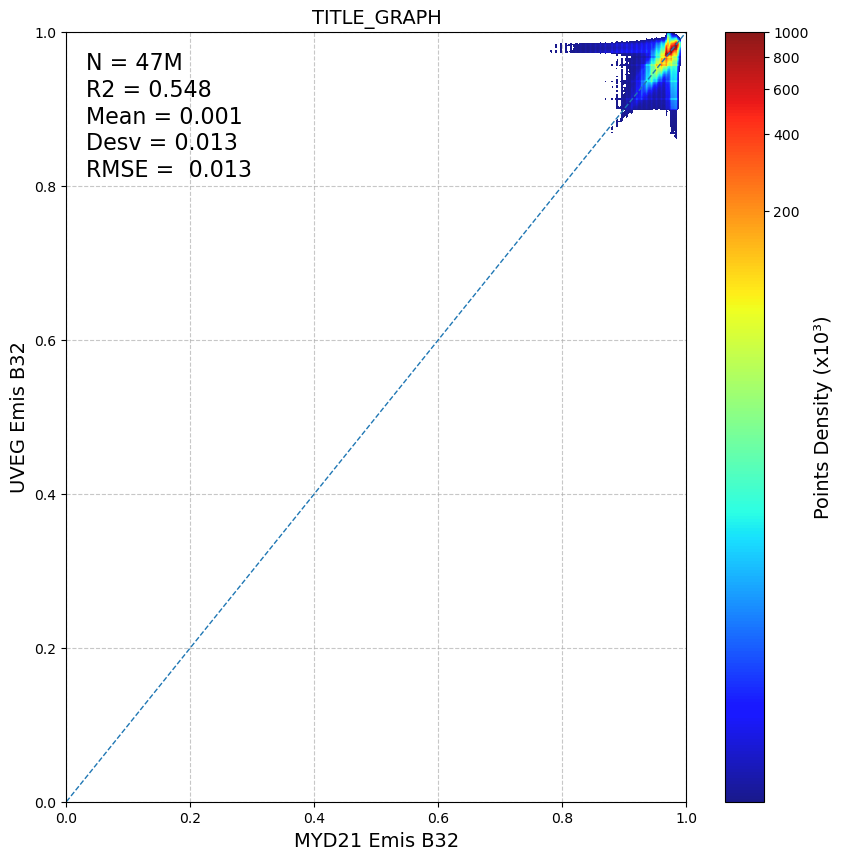

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_scatter_density import ScatterDensityArtist, ScatterDensityAxes
from astropy.visualization import ImageNormalize, LogStretch
from matplotlib.ticker import FuncFormatter

def density_scatter( path_save, title_graph_lst, x , y):
    """
    Scatter plot colored by 2d histogram
    """
    MIN_LIMIT = 0
    MAX_LIMIT = 1
    INTERVAL = 0.1


    # Ajusta los parámetros para optimizar el gráfico de dispersión con densidad
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density', facecolor='white')
    ax.grid(True, linestyle='--', alpha=0.7)

    norm = ImageNormalize(vmin=100, vmax=1000000, stretch=LogStretch())
    density = ax.scatter_density(x, y, cmap=palette, alpha=0.9, norm=norm)
    
    plt.plot([MIN_LIMIT, MAX_LIMIT], [MIN_LIMIT, MAX_LIMIT], linestyle='--', linewidth=1)
    a = 1
    def formatear_en_millones(num):
        if num >= 1e6:
            return f'{num/1e6:.0f}M'
        else:
            return f'{num:.0f}'
    plt.plot(a, label='N = '+str(formatear_en_millones(np.ma.count(x)))  + '\n' + 'R2 = ' + str(np.round(r2_21,3)) + '\n' +  'Mean = ' + str("{:.{}f}".format(np.abs(np.nanmean(dif_lstR_temp21)),3))  + '\n' + 'Desv = ' + str(np.round(np.nanstd(dif_lstR_temp21),3)) + '\n' + 'RMSE =  ' + str(np.round(rmse21,3)) )
    # plt.plot(a, label='N = '+str('489M')  + '\n' + 'R2 = ' + str(np.round(r2_21,3)) + '\n' +  'Mean = ' + str("{:.{}f}".format(np.abs(np.nanmean(dif_lstR_temp21)),2))  + '\n' + 'Desv = ' + str(np.round(np.nanstd(dif_lstR_temp21),2)) + '\n' + 'RMSE =  ' + str(np.round(rmse21,2)) )

    plt.legend(markerscale=1, numpoints= 1, loc='best', shadow=False, fontsize='16', frameon = False, markerfirst=None, handlelength=0.0)
    #legend.get_frame().set_facecolor('white')
    
    # plt.xticks(range(MIN_LIMIT, MAX_LIMIT, INTERVAL),fontsize='14')
    # plt.yticks(range(MIN_LIMIT, MAX_LIMIT, INTERVAL),fontsize='14')
    plt.title(title_graph_lst, fontsize='14')
    plt.xlabel('MYD21 Emis B32', fontsize='14')
    plt.ylabel('UVEG Emis B32', fontsize='14')
    # plt.savefig(path_save + title_graph_lst + 'lst21.jpg')

    ax.set_xlim(MIN_LIMIT, MAX_LIMIT)
    ax.set_ylim(MIN_LIMIT, MAX_LIMIT)

    # Define una función de formato personalizado para la barra de colores
    def format_ticks(value, _):
        if value >= 1e4:
            return f'{value/1e3:.0f}'
        elif value >= 1e3:
            return f'{value/1e3:.1f}'
        else:
            return f'{value:.0f}'
    cbar = plt.colorbar(density, format=FuncFormatter(format_ticks))
    cbar.set_label('Points Density (x10³)', fontsize='14')

    plt.show()
    
    # return ax


if "__main__" == __name__ :

    density_scatter('path_save', 'TITLE_GRAPH' ,array_temp21_ravel_mask_lst, array_lst_R_ravel_mask_lst)
    
